In [8]:
#1.Import Liabraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
#2. Load Dataset

df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
#3. Data Validation

df.shape
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500.000000,55500,55500,55500,55500,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55500
unique,49992,NaN,2,8,6,1827,40341,39876,5,NaN,NaN,3,1856,5,3
top,DAvId muNoZ,NaN,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,2020-03-15,Lipitor,Abnormal
freq,3,NaN,27774,6969,9308,50,27,44,11249,NaN,NaN,18655,53,11140,18627
mean,NaN,51.539459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25539.316097,301.134829,NaN,NaN,NaN,NaN
std,NaN,19.602454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.454431,115.243069,NaN,NaN,NaN,NaN
min,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2008.492140,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13241.224652,202.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25538.069376,302.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37820.508436,401.000000,NaN,NaN,NaN,NaN


In [5]:
#4. Missing Values Check

df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [10]:
#5. Data Cleaning
df=df.drop_duplicates()
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")
df['gender'] = df['gender'].str.lower().str.strip()

df['gender'] = df['gender'].replace({
    'm': 'male',
    'f': 'female',
    'male ': 'male',
    'female ': 'female'
})

df['age'] = pd.to_numeric(df['age'], errors='coerce')

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

    obj_cols = df.select_dtypes(include=['object']).columns
for col in obj_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

    df['medical_condition']=df['medical_condition'].str.lower().str.strip()

In [11]:
#6. Demographic Categorization

bins = [0, 18, 35, 60, 120]
labels = ['0-18', '19-35', '36-60', '60+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

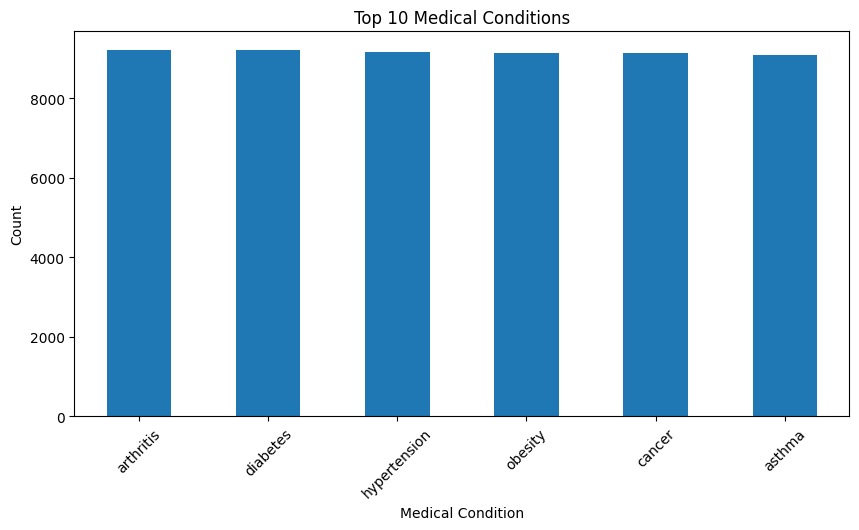

In [13]:
#7. Medical Condition Analysis

    #1. Top Medical Conditions
plt.figure(figsize=(10,5))
df['medical_condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Medical Conditions")
plt.xlabel("Medical Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

    

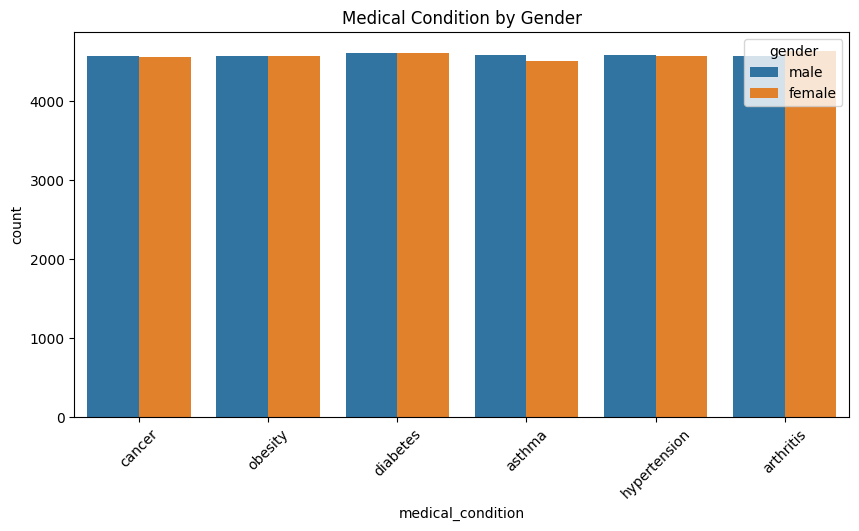

In [17]:
    #2. Medical Condition by Gender
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='medical_condition', hue='gender')
plt.xticks(rotation=45)
plt.title("Medical Condition by Gender")
plt.show()

    

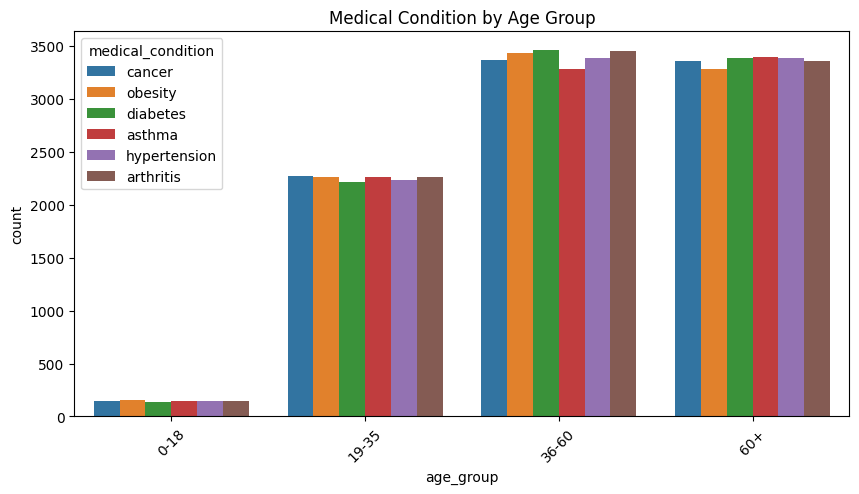

In [18]:
    #3. Medical Condition by Age Group
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='age_group', hue='medical_condition')
plt.title("Medical Condition by Age Group")
plt.xticks(rotation=45)
plt.show()

In [20]:
#8. High Risk Group Analysis

high_risk_age = df['age_group'].value_counts()
print(high_risk_age)



age_group
36-60    20389
60+      20172
19-35    13519
0-18       886
Name: count, dtype: int64


In [21]:
print(df['gender'].value_counts())



gender
male      27496
female    27470
Name: count, dtype: int64


In [22]:
risk_analysis = df.groupby(['age_group', 'gender']).size().sort_values(ascending=False)
print(risk_analysis.head(10))

age_group  gender
36-60      male      10259
           female    10130
60+        female    10109
           male      10063
19-35      female     6778
           male       6741
0-18       female      453
           male        433
dtype: int64


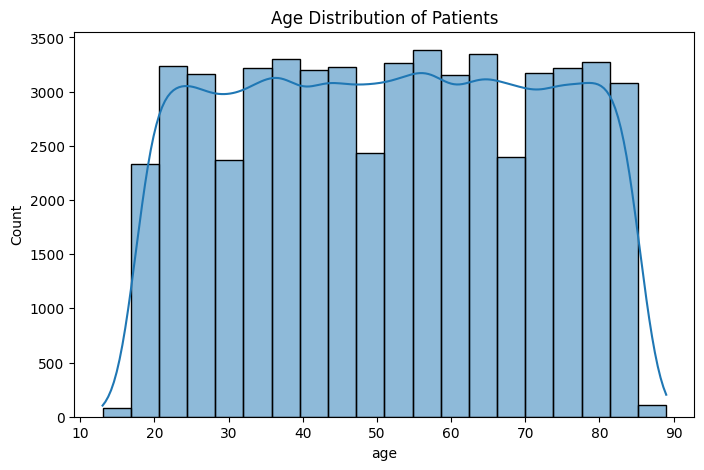

In [23]:
#9 Age Distribution Plot

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.show()